In [2]:
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
import pickle

from open_iris_client import EyeData, EyesData, ExtraData

root = Path('/home/dan/work/CNS-OpenIrisDAC')


In [3]:
def edgenerator(filename):
    with open(filename,'rb') as f:
        while True:
            try:
                ed = pickle.load(f)
                yield ed
            except EOFError:
                break


In [ ]:
#root = Path('/home/dan/work/CNS-OpenIrisDAC')
n = 0
#with open(root/'cal3.pkl','rb') as f:
for ed in edgenerator(root/'cal4.pkl'):
    n += 1
print(n)

# now allocate arrays and fill them
datashape = (n,2)
frame_number_array = np.zeros(n)
pupil_array = np.zeros(datashape)
cr_array = np.zeros(datashape)
p4_array = np.zeros(datashape)
pupil_scatter_array = np.zeros(datashape)
cr_scatter_array = np.zeros(datashape)
p4_scatter_array = np.zeros(datashape)
scatter_count = 0
counter = 0
button_up = True

for ed in edgenerator(root/'cal4.pkl'):
    data_ok = True
    if ed.left.pupil.x == 0 or ed.left.pupil.y == 0:
        pupil_array[counter,:] = np.nan
        data_ok = False
    else:
        pupil_array[counter,0] = ed.left.pupil.x
        pupil_array[counter,1] = ed.left.pupil.y
    frame_number_array[counter] = ed.left.frame_number
    if ed.left.cr.x == -100 or ed.left.cr.y == -100:
        cr_array[counter,:] = np.nan
        data_ok = False
    else:
        cr_array[counter,0] = ed.left.cr.x
        cr_array[counter,1] = ed.left.cr.y
    if ed.left.p4.x == 820 or ed.left.p4.y == -100:
        p4_array[counter,:] = np.nan
        data_ok = False
    else:
        p4_array[counter,0] = ed.left.p4.x
        p4_array[counter,1] = ed.left.p4.y

    button_is_pressed = ed.extra.ints[8] & 0x1
    if button_up:
        if button_is_pressed:
            button_up = False
            if data_ok:
                pupil_scatter_array[scatter_count,:] = [ed.left.pupil.x, ed.left.pupil.y]
                cr_scatter_array[scatter_count,:] = [ed.left.cr.x, ed.left.cr.y]
                p4_scatter_array[scatter_count,:] = [ed.left.p4.x, ed.left.p4.y]
                scatter_count += 1
            else:
                print('button down no data')
    else:
        if not button_is_pressed:
            button_up = True
 
    counter += 1        


print("Found {} frames".format(counter))
print("Found {} button presses".format(scatter_count))

#     while True:
#         try:
#             ed = pickle.load(f)
#             #print(ed.left.frame_number)
#             counter += 1
#         except EOFError:
#             break
# print(counter)


74071


IndexError: index 74071 is out of bounds for axis 0 with size 74071

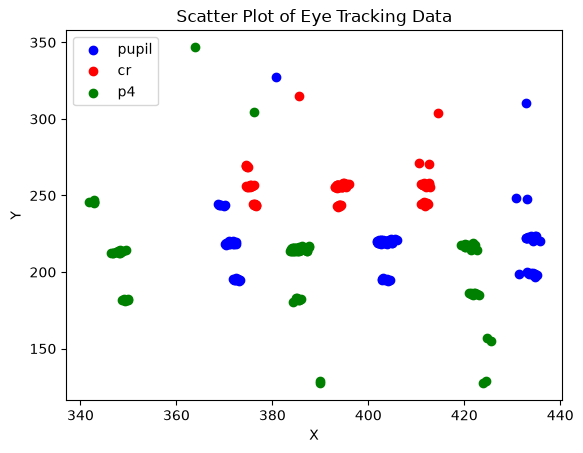

In [5]:
plt.scatter(pupil_scatter_array[:scatter_count,0], pupil_scatter_array[:scatter_count,1], color='blue', label='pupil')
plt.scatter(cr_scatter_array[:scatter_count,0], cr_scatter_array[:scatter_count,1], color='red', label='cr')
plt.scatter(p4_scatter_array[:scatter_count,0], p4_scatter_array[:scatter_count,1], color='green', label='p4')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot of Eye Tracking Data')
plt.legend()
plt.show()

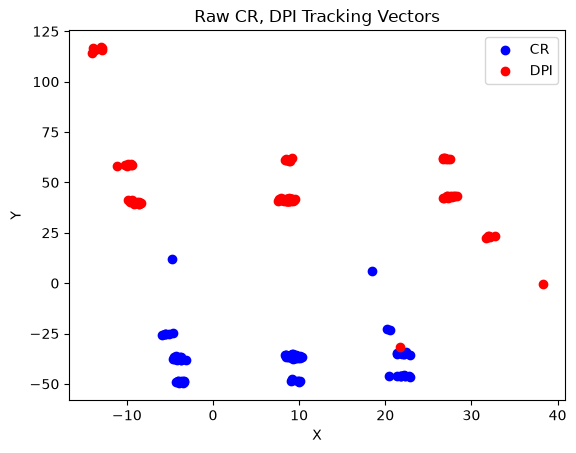

In [7]:
cr_sig = pupil_scatter_array[:scatter_count,:] - cr_scatter_array[:scatter_count,:]
dpi_sig = cr_scatter_array[:scatter_count,:] - p4_scatter_array[:scatter_count,:]

plt.scatter(cr_sig[:scatter_count,0], cr_sig[:scatter_count,1], color='blue', label='CR')
plt.scatter(dpi_sig[:scatter_count,0], dpi_sig[:scatter_count,1], color='red', label='DPI')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Raw CR, DPI Tracking Vectors')
plt.legend()
plt.show()

In [ ]:
plt.ion()  # interactive mode

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plt.tight_layout(pad=2.5)
ax1.plot(frame_number_array, pupil_array[:,0], label='pupil x')
ax1.plot(frame_number_array, pupil_array[:,1], label='pupil y')
ax1.plot(frame_number_array, cr_array[:,0], label='CR x')
ax1.plot(frame_number_array, cr_array[:,1], label='CR y')
ax1.plot(frame_number_array, p4_array[:,0], label='p4 x')
ax1.plot(frame_number_array, p4_array[:,1], label='p4 y')
ax1.set_xlabel('Frame Number')
ax1.set_ylabel('Position (pixels)')
ax1.set_title('Pupil, CR, and P4 Positions Over Time')
ax1.legend()
ax1.grid()

ax2.plot(frame_number_array, pupil_array[:,0] - cr_array[:,0], label='pupil x - CR x')
ax2.plot(frame_number_array, pupil_array[:,1] - cr_array[:,1], label='pupil y - CR y')
ax2.plot(frame_number_array, p4_array[:,0] - cr_array[:,0], label='p4 x - CR x')
ax2.plot(frame_number_array, p4_array[:,1] - cr_array[:,1], label='p4 y - CR y')
ax2.set_xlabel('Frame Number')
ax2.set_ylabel('Position Difference (pixels)')
ax2.set_title('Position Differences Over Time')
ax2.legend()
ax2.grid()
plt.show()

In [ ]:
np.max(p4_array[:,0])